In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df =pd.read_csv("Dataset_Day14.csv")

In [15]:
display(df.head())
display(df.info())

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


None

In [16]:
df.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [17]:
#No missing values
# scaling
df_new = pd.DataFrame()
for i in df.columns:
    if df[i].dtype.name !='object':
        df_new[i] = (df[i] - df[i].mean())/df[i].std()

df_new.drop(columns=['Id'],inplace=True)
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [18]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN().fit(df_new)

clusters = dbscan.labels_
display(pd.DataFrame(clusters).value_counts(normalize=True)*100)

0 
 1    47.333333
 0    29.333333
-1    23.333333
Name: proportion, dtype: float64

Observations:-

The data has been grouped into two clusters: Label 0 and Label 1.

About 23.33% of the data has been marked as outliers, which is quite high.

This means the value chosen for eps (a parameter that controls the size of clusters) might not be the best.

To get better results, we should try different eps values and find the most suitable one.

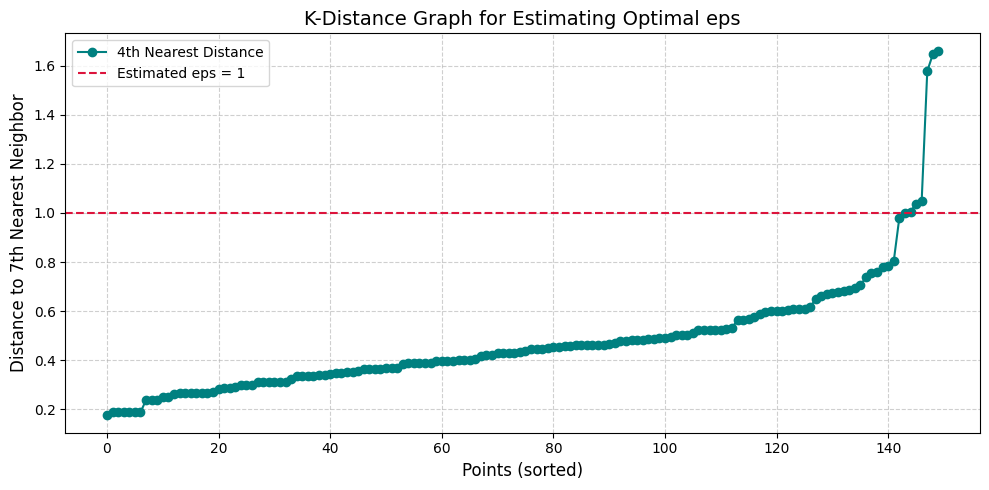

In [19]:
from sklearn.neighbors import NearestNeighbors


k = 4
nn = NearestNeighbors(n_neighbors=k)
nn.fit(df_new)


distances, indices = nn.kneighbors(df_new)
k_distances = np.sort(distances[:, k - 1])


plt.figure(figsize=(10, 5))
plt.plot(k_distances, marker='o', linestyle='-', color='teal', label=f'{k}th Nearest Distance')
plt.axhline(y=1, color='crimson', linestyle='--', linewidth=1.5, label='Estimated eps = 1')
plt.title('K-Distance Graph for Estimating Optimal eps', fontsize=14)
plt.xlabel('Points (sorted)', fontsize=12)
plt.ylabel('Distance to 7th Nearest Neighbor', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Observations:-

The red dashed line marks the estimated optimal eps = 1.
Points below the eps = 1.0 line are likely within dense regions.

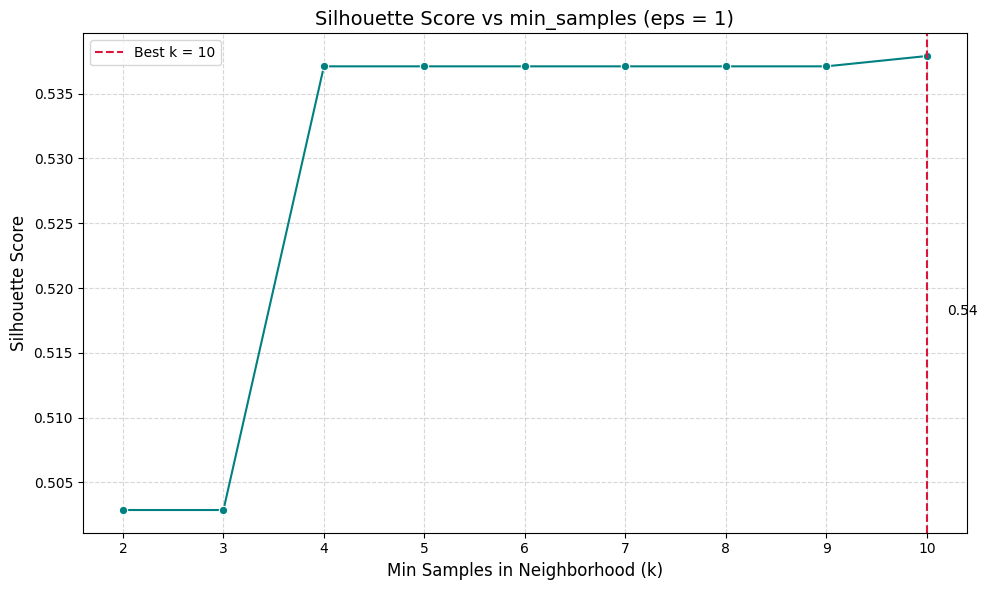

In [20]:
#Use the ‘eps’ value in (2.) and find the most optimal value of ‘min_samples’ using silhouette score.
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Try different min_samples values with fixed eps
eps_value = 1
ss = []

min_samples_range = range(2, 11)
for k in min_samples_range:
    dbscan = DBSCAN(eps=eps_value, min_samples=k).fit(df_new)
    if len(set(dbscan.labels_)) > 1 and -1 in dbscan.labels_:
        score = silhouette_score(df_new, dbscan.labels_)
    else:
        score = -1  
    ss.append(score)

ss_series = pd.Series(ss, index=min_samples_range)

# Step 3: Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=ss_series.index, y=ss_series.values, color='teal', marker='o')


# Highlight max silhouette score
best_k = ss_series.idxmax()
best_score = ss_series.max()
plt.axvline(x=best_k, linestyle='--', color='crimson', label=f'Best k = {best_k}')
plt.text(best_k + 0.2, best_score - 0.02, f"{best_score:.2f}", color='black')


plt.xlabel('Min Samples in Neighborhood (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title(f'Silhouette Score vs min_samples (eps = {eps_value})', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Observations:-

The highest silhouette score (~0.54) is achieved when min_samples = 10, indicated by the red dashed line.
There’s a sharp jump in silhouette score from 3 to 4, and after that, the score remains quite stable or slightly improves.
For eps = 1, the most optimal min_samples value is 10, as it leads to the best cluster structure in terms of cohesion and separation.

In [23]:
df_new_labeled = df_new.copy()
df_new_labeled['Cluster'] = clusters
outliers = df_new_labeled[df_new_labeled['Cluster'] == -1]
print("Outliers detected by DBSCAN:")
print(outliers)

Outliers detected by DBSCAN:
     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Cluster
41       -1.622254     -1.738953      -1.393470     -1.177559       -1
117       2.242172      1.720502       1.667025      1.312087       -1
131       2.483699      1.720502       1.496998      1.050019       -1


In [24]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1, min_samples= 4).fit(df_new)

clusters = dbscan.labels_
display(pd.DataFrame(clusters).value_counts(normalize=True)*100)


0 
 1    65.333333
 0    32.666667
-1     2.000000
Name: proportion, dtype: float64

In [ ]:
Observations:-

A total of 2% outliers were detected by DBSCAN, which means they didn’t fit into any of the dense groups formed during clustering.
A few points (e.g., index 41, 117, and 131) were detected as outliers.
Index 41 has very low values for all features, indicating it lies far from dense regions
On the other hand, indices 117, and 131 have high values in SepalLengthCm, SepalWidthCm, and PetalLengthCm, making them outliers from the opposite end (upper tail).